# Titanic Survival Prediction using Machine Learning

## Problem Statement
Predict whether a passenger survived the Titanic disaster based on passenger information such as age, gender, passenger class, fare, family information, etc.

## Target Variable
Survived

0 = Did Not Survive
1 = Survived

## Problem Type
Binary Classification

In [680]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [681]:
df=pd.read_csv('titanic.csv')

In [682]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [683]:
r=df.shape[0]
c=df.shape[1]

print(f'No.of rows = {r}')
print(f'No.of columns = {c}')

No.of rows = 891
No.of columns = 12


In [684]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [685]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Numerical Columns - PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare

Categorical Features stored as numbers: Survived, Pclass

Columns - Age, Cabin,Embarked has NULL values

In [686]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age column has 177 NULL values

Cabin column has 687 NULL values

Embarked column has 2 NULL values

In [687]:
null_age_perc=(177/891)*100
null_cabin_perc=(687/891)*100
null_Embarked_perc=(2/891)*100

print(f'Percentage of null values in Age column is {null_age_perc:.2f}%')
print(f'Percentage of null values in cabin column is {null_cabin_perc:.2f}%')
print(f'Percentage of null values in Embarked column is {null_Embarked_perc:.2f}%')

Percentage of null values in Age column is 19.87%
Percentage of null values in cabin column is 77.10%
Percentage of null values in Embarked column is 0.22%


##### Cabin column has Highest percentage of NULL values

Age:
Important feature. Missing values will be handled instead of dropping the column.

Embarked:
Contains only 2 missing values. Missing values will be handled.

Cabin:
May contain useful information, but 77.10% of values are missing. Therefore, the column will be removed.

In [688]:
df.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [689]:
df.Embarked

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [690]:
df['Age'].mean()

np.float64(29.69911764705882)

In [691]:
df['Age'].median()

np.float64(28.0)

In [692]:
df['Age'].mode()

0    24.0
Name: Age, dtype: float64

In [693]:
df['Age'].min()

np.float64(0.42)

In [694]:
df['Age'].max()

np.float64(80.0)

#### Age column contains some extreme values (outliers). Since mean can be affected by outliers, median is a best measure. Therefore, missing values in the Age column were filled using the median value.

In [695]:
df.groupby('Embarked').count()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
Embarked,,,,,,,,,,,
C,168,168,168,168,168,130,168,168,168,168,69
Q,77,77,77,77,77,28,77,77,77,77,4
S,644,644,644,644,644,554,644,644,644,644,129


#### Embarked is a categorical feature. Mean and median cannot be applied to categorical data. Therefore, missing values in the Embarked column were filled using the mode (most frequent category).

#### Cabin column contains 77.10% missing values. Since a large portion of the data is unavailable, the column was dropped from the dataset.

In [696]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True)

In [697]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

#### No NULL values now.

In [698]:
df.duplicated().sum()

np.int64(0)

#### No duplicate rows are present in the dataset. Therefore, no duplicate removal is required.

In [699]:
df.groupby('Survived').count()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
Survived,,,,,,,,,,
0,549,549,549,549,549,549,549,549,549,549
1,342,342,342,342,342,342,342,342,342,342


In [700]:
perc_surv=(342/891)*100
perc_notsurv=(549/891)*100
print('Number of passengers survived: 342')
print('Number of passengers not survived: 549')
print(f'Percentage of people survived is {perc_surv:.2f}%')
print(f'Percentage of people not survived is {perc_notsurv:.2f}%')

Number of passengers survived: 342
Number of passengers not survived: 549
Percentage of people survived is 38.38%
Percentage of people not survived is 61.62%


#### Only 38.38% of passengers survived, while 61.62% did not survive. This indicates that survival was relatively rare compared to non-survival during the Titanic disaster.

In [701]:
df.groupby(['Sex','Survived']).count()

PassengerId  Pclass  Name  Age  SibSp  Parch  Ticket  Fare  \
Sex    Survived                                                               
female 0                  81      81    81   81     81     81      81    81   
       1                 233     233   233  233    233    233     233   233   
male   0                 468     468   468  468    468    468     468   468   
       1                 109     109   109  109    109    109     109   109   

                 Embarked  
Sex    Survived            
female 0               81  
       1              233  
male   0              468  
       1              109

##### Count of Females survived: 233
##### Count of Females not survived: 81
##### Count of Males survived: 109
##### Count of Males not survived: 468

In [702]:
Female_Survival_Rate=(233/(81+233))*100
Male_Survival_Rate=(109/(109+468))*100

print(f'Female survival rate: {Female_Survival_Rate:.2f}%')
print(f'Male survival rate: {Male_Survival_Rate:.2f}%')

Female survival rate: 74.20%
Male survival rate: 18.89%


#### Female passengers had a significantly higher survival rate compared to male passengers.
#### Approximately 74% of female passengers survived, whereas only about 19% of male passengers survived.
#### This suggests that gender was one of the strongest factors influencing survival during the Titanic disaster.

In [703]:
df.groupby(['Pclass','Survived']).count()

PassengerId  Name  Sex  Age  SibSp  Parch  Ticket  Fare  \
Pclass Survived                                                            
1      0                  80    80   80   80     80     80      80    80   
       1                 136   136  136  136    136    136     136   136   
2      0                  97    97   97   97     97     97      97    97   
       1                  87    87   87   87     87     87      87    87   
3      0                 372   372  372  372    372    372     372   372   
       1                 119   119  119  119    119    119     119   119   

                 Embarked  
Pclass Survived            
1      0               80  
       1              136  
2      0               97  
       1               87  
3      0              372  
       1              119

In [704]:
class1_surv_rate=(136/(136+80))*100
class2_surv_rate=(87/(87+97))*100
class3_surv_rate=(119/(119+372))*100

print(f'Survival rate of passengers in class1: {class1_surv_rate:.2f}%')
print(f'Survival rate of passengers in class2: {class2_surv_rate:.2f}%')
print(f'Survival rate of passengers in class3: {class3_surv_rate:.2f}%')

Survival rate of passengers in class1: 62.96%
Survival rate of passengers in class2: 47.28%
Survival rate of passengers in class3: 24.24%


#### Passenger class had a significant impact on survival.
#### Passengers travelling in First Class had the highest survival rate (62.96%), while passengers in Third Class had the lowest survival rate (24.24%).
#### This suggests that passengers in higher classes were more likely to survive than those in lower classes.

In [705]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [706]:
df.groupby('Survived')['Age'].min()

Survived
0    1.00
1    0.42
Name: Age, dtype: float64

In [707]:
df.groupby('Survived')['Age'].max()

Survived
0    74.0
1    80.0
Name: Age, dtype: float64

#### Average age of survivors (28.29 years) was slightly lower than the average age of non-survivors (30.03 years). However, the difference is relatively small, suggesting that age alone may not have been a strong factor influencing survival.

In [708]:
df.groupby(['Embarked','Survived']).count()

PassengerId  Pclass  Name  Sex  Age  SibSp  Parch  Ticket  \
Embarked Survived                                                              
C        0                  75      75    75   75   75     75     75      75   
         1                  93      93    93   93   93     93     93      93   
Q        0                  47      47    47   47   47     47     47      47   
         1                  30      30    30   30   30     30     30      30   
S        0                 427     427   427  427  427    427    427     427   
         1                 219     219   219  219  219    219    219     219   

                   Fare  
Embarked Survived        
C        0           75  
         1           93  
Q        0           47  
         1           30  
S        0          427  
         1          219

In [709]:
embarked_C_surv_rate=(93/(93+75))*100
embarked_Q_surv_rate=(30/(30+47))*100
embarked_S_surv_rate=(219/(219+427))*100

print(f'Survival rate of passengers who embarked from C: {embarked_C_surv_rate:.2f}%')
print(f'Survival rate of passengers who embarked from Q: {embarked_Q_surv_rate:.2f}%')
print(f'Survival rate of passengers who embarked from S: {embarked_S_surv_rate:.2f}%')

Survival rate of passengers who embarked from C: 55.36%
Survival rate of passengers who embarked from Q: 38.96%
Survival rate of passengers who embarked from S: 33.90%


#### Passengers who embarked from C had the highest survival rate (55.36%).
#### Passengers who embarked from S had the lowest survival rate (33.90%).
#### Therefore, the embarkation port appears to have some influence on passenger survival.

In [710]:
df.Fare.min()

np.float64(0.0)

In [711]:
df.Fare.max()

np.float64(512.3292)

In [712]:
df.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

#### The average fare paid by survivors was 48.40, while the average fare paid by non-survivors was 22.12.
#### This suggests that passengers paying higher fares had a greater chance of survival.
#### Since higher fares were generally associated with higher passenger classes, fare appears to be an important factor influencing survival.

In [713]:
df['Familysize']=df['SibSp']+df['Parch']+1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [714]:
df['Familysize'].min()

np.int64(1)

In [715]:
df['Familysize'].max()

np.int64(11)

In [716]:
df.groupby('Survived')['Familysize'].mean()

Survived
0    1.883424
1    1.938596
Name: Familysize, dtype: float64

#### The average family size of survivors (1.94) was slightly higher than that of non-survivors (1.88). However, the difference is very small, suggesting that family size alone may not have had a strong influence on survival.

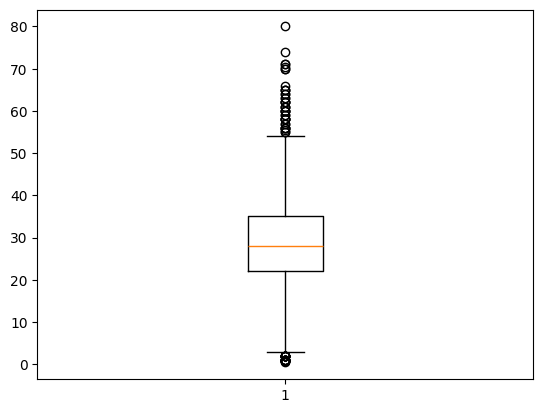

In [717]:
plt.boxplot(df['Age'])
plt.show()

##### Age contains outliers. However, these values are realistic ages of passengers and not data errors. Therefore, Age outliers should be retained.

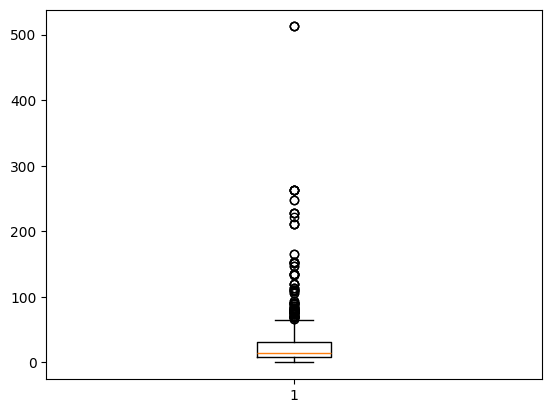

In [718]:
plt.boxplot(df['Fare'])
plt.show()

##### Fare contains a significant number of extreme outliers. However, these high fares represent actual ticket prices paid by wealthy passengers and are not data entry errors. Therefore, Fare outliers should be retained.

#### Both Age and Fare contain outliers.
#### Fare shows a much higher degree of variation and contains more extreme values than Age.
#### Since these outliers represent genuine passenger information rather than errors, they were retained in the dataset.

In [719]:
numerical_columns=['Survived','Pclass','Age','Fare','SibSp','Parch','Familysize']
corr_matrix=df[numerical_columns].corr()
corr_matrix

,Survived,Pclass,Age,Fare,SibSp,Parch,Familysize
Survived,1.000000,-0.338481,-0.064910,0.257307,-0.035322,0.081629,0.016639
Pclass,-0.338481,1.000000,-0.339898,-0.549500,0.083081,0.018443,0.065997
Age,-0.064910,-0.339898,1.000000,0.096688,-0.233296,-0.172482,-0.245619
Fare,0.257307,-0.549500,0.096688,1.000000,0.159651,0.216225,0.217138
SibSp,-0.035322,0.083081,-0.233296,0.159651,1.000000,0.414838,0.890712
Parch,0.081629,0.018443,-0.172482,0.216225,0.414838,1.000000,0.783111
Familysize,0.016639,0.065997,-0.245619,0.217138,0.890712,0.783111,1.000000


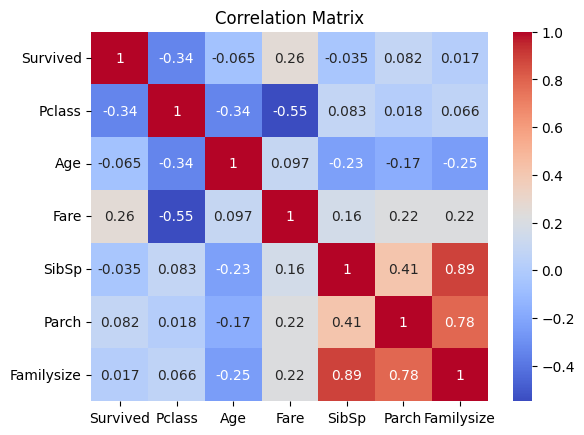

In [720]:
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### Correlation analysis shows that Pclass has the strongest negative correlation with survival (-0.34), indicating that passengers in lower classes were less likely to survive.
#### Fare has a positive correlation with survival (0.26), suggesting that passengers paying higher fares had better survival chances.
#### Age, SibSp, Parch, and FamilySize show weak correlations with survival, indicating limited individual influence on passenger survival.

In [721]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [722]:
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1


In [723]:
df['Sex'].unique()

array([0, 1])

In [724]:
df['Embarked'].unique()

array([0, 1, 2])

##### Did encoding as ml algorithms cannot process text, so encoded text columns to numericals

In [725]:
df.drop(columns=['PassengerId','Name','Ticket'],inplace=True)

In [726]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Familysize
0,0,3,0,22.0,1,0,7.2500,0,2
1,1,1,1,38.0,1,0,71.2833,1,2
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,2
4,0,3,0,35.0,0,0,8.0500,0,1


#### Resons for dropping the columns:
#### PassengerId is a unique identifier assigned to each passenger and does not provide meaningful information for predicting survival
#### Name is a text-based feature that cannot be directly used by machine learning models and was not further processed in this project.
#### Ticket contains mostly unique ticket numbers with limited predictive value and may introduce unnecessary complexity to the model.

In [727]:
X=df.iloc[:,1:]
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Familysize
0,3,0,22.0,1,0,7.2500,0,2
1,1,1,38.0,1,0,71.2833,1,2
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,0,2
4,3,0,35.0,0,0,8.0500,0,1


In [728]:
y=df['Survived']
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [729]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [730]:
X_train.shape

(712, 8)

In [731]:
y_train.shape

(712,)

In [732]:
X_test.shape

(179, 8)

In [733]:
y_test.shape

(179,)

In [734]:
dt=DecisionTreeClassifier(random_state=39)

In [735]:
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",39
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [736]:
y_pred=dt.predict(X_test)

In [737]:
test_accuracy=accuracy_score(y_test,y_pred)
print(f'Test Accuracy is: {test_accuracy*100:.2f}%')

Test Accuracy is: 74.30%


In [738]:
confusionmatrix=confusion_matrix(y_test,y_pred)
print(confusionmatrix)

[[94 16]
 [30 39]]


In [752]:
classificationreport=classification_report(y_test,y_pred,output_dict=True)
print(classificationreport)

{'0': {'precision': 0.7580645161290323, 'recall': 0.8545454545454545, 'f1-score': 0.8034188034188035, 'support': 110.0}, '1': {'precision': 0.7090909090909091, 'recall': 0.5652173913043478, 'f1-score': 0.6290322580645161, 'support': 69.0}, 'accuracy': 0.7430167597765364, 'macro avg': {'precision': 0.7335777126099707, 'recall': 0.7098814229249011, 'f1-score': 0.7162255307416598, 'support': 179.0}, 'weighted avg': {'precision': 0.739186421795901, 'recall': 0.7430167597765364, 'f1-score': 0.7361971742040224, 'support': 179.0}}


In [740]:
x_pred=dt.predict(X_train)

In [741]:
train_accuracy=accuracy_score(y_train,x_pred)
print(f'Train Accuracy is: {train_accuracy*100:.2f}%')

Train Accuracy is: 98.31%


#### The Decision Tree model achieved a training accuracy of 98.31% and a testing accuracy of 74.30%.

#### The model performed extremely well on the training data but showed a noticeable drop in testing accuracy. This indicates that the model has overfitted the training dataset and is not generalizing well to unseen data.

#### To improve model performance and reduce overfitting, a Random Forest Classifier will be used and compared with the Decision Tree model.

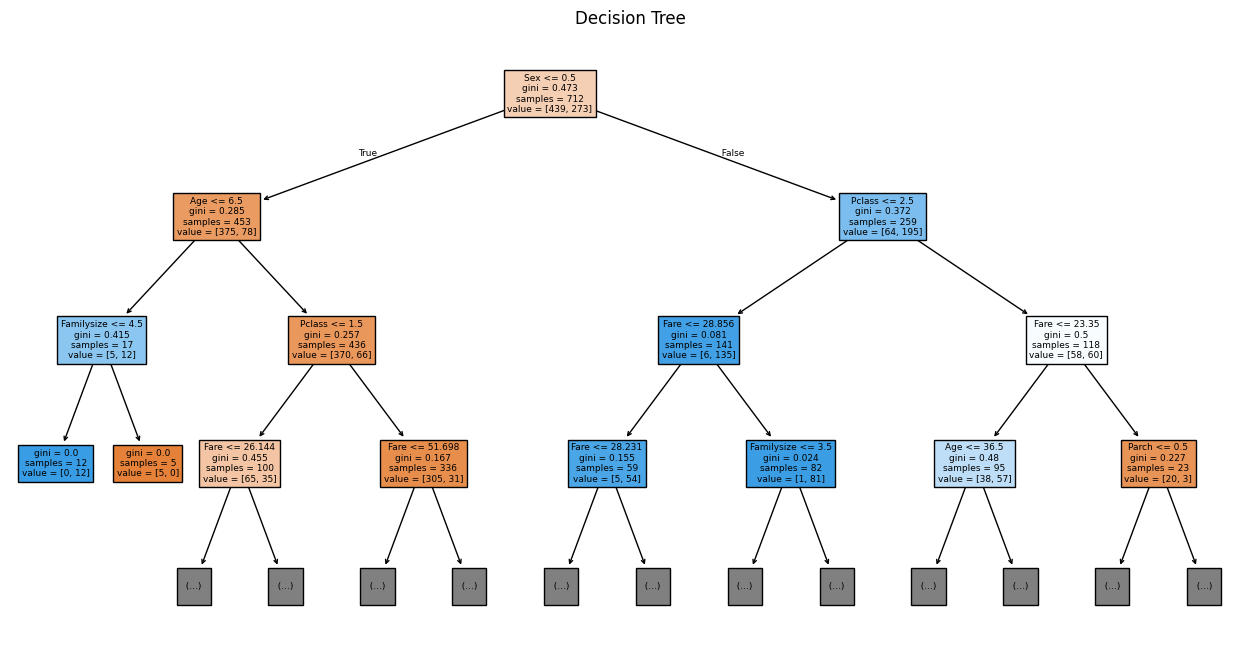

In [742]:
plt.figure(figsize=(16,8))
plot_tree(dt,filled=True,feature_names=X.columns,max_depth=3)
plt.title('Decision Tree')
plt.show()

In [743]:
rf=RandomForestClassifier(random_state=25)

In [744]:
rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",25
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [745]:
y_pred_rf=rf.predict(X_test)

In [746]:
random_test_accuracy=accuracy_score(y_test,y_pred_rf)
print(f'Test Accuracy is : {random_test_accuracy*100:.2f}%')

Test Accuracy is : 78.21%


In [747]:
random_confusionmatrix=confusion_matrix(y_test,y_pred_rf)
print(random_confusionmatrix.T)

[[98 27]
 [12 42]]


In [748]:
random_classificationreport=classification_report(y_test,y_pred_rf,output_dict=True)
print(random_classificationreport)

{'0': {'precision': 0.784, 'recall': 0.8909090909090909, 'f1-score': 0.8340425531914893, 'support': 110.0}, '1': {'precision': 0.7777777777777778, 'recall': 0.6086956521739131, 'f1-score': 0.6829268292682927, 'support': 69.0}, 'accuracy': 0.7821229050279329, 'macro avg': {'precision': 0.780888888888889, 'recall': 0.749802371541502, 'f1-score': 0.758484691229891, 'support': 179.0}, 'weighted avg': {'precision': 0.7816014897579143, 'recall': 0.7821229050279329, 'f1-score': 0.7757912406177432, 'support': 179.0}}


In [749]:
x_pred_rf=rf.predict(X_train)

In [750]:
random_train_accuracy=accuracy_score(y_train,x_pred_rf)
print(f'Train Accuracy is : {random_train_accuracy*100:.2f}%')

Train Accuracy is : 98.31%


In [753]:
Score_matrix=pd.DataFrame({'Model':['DecisionTreeClassifier','RandomForestClassifier'],
                           'Test_Accuracy':[test_accuracy,random_test_accuracy],
                           'Train_Accuracy':[train_accuracy,random_train_accuracy],
                           'Precision':[classificationreport['weighted avg']['precision'],random_classificationreport['weighted avg']['precision']],
                           'Recall':[classificationreport['weighted avg']['recall'],random_classificationreport['weighted avg']['recall']],
                           'F1score':[classificationreport['weighted avg']['f1-score'],random_classificationreport['weighted avg']['f1-score']]
    
})

Score_matrix

,Model,Test_Accuracy,Train_Accuracy,Precision,Recall,F1score
0,DecisionTreeClassifier,0.743017,0.983146,0.739186,0.743017,0.736197
1,RandomForestClassifier,0.782123,0.983146,0.781601,0.782123,0.775791


#### Random Forest achieved higher Test Accuracy (78.21%) than Decision Tree (74.30%).
#### Random Forest also achieved better Precision, Recall, and F1 Score.
#### Both models show very high Training Accuracy (98.31%), indicating some degree of overfitting.
#### Despite this, Random Forest generalized better on unseen data and outperformed the Decision Tree model.
#### Therefore, Random Forest was selected as the final model for passenger survival prediction.

In [755]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Familysize'],
      dtype='str')

In [757]:
feature_imp=rf.feature_importances_
feature_imp

array([0.08513491, 0.27960668, 0.23667691, 0.03039679, 0.02828742,
       0.25117806, 0.03651195, 0.05220729])

In [766]:
feature_importances=pd.DataFrame({'Feature_name':X.columns,
                                  'Feature_importance':feature_imp})

feature_importances=feature_importances.sort_values(
    by='Feature_importance',
    ascending=False
)

feature_importances

,Feature_name,Feature_importance
1,Sex,0.279607
5,Fare,0.251178
2,Age,0.236677
0,Pclass,0.085135
7,Familysize,0.052207
6,Embarked,0.036512
3,SibSp,0.030397
4,Parch,0.028287


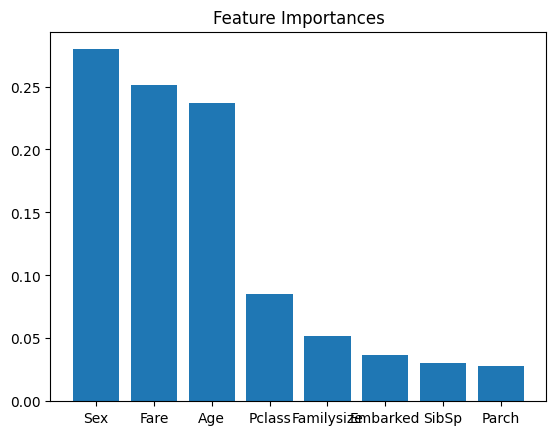

In [767]:
plt.figure()
plt.bar(feature_importances['Feature_name'],feature_importances['Feature_importance'])
plt.title('Feature Importances')
plt.show()

#### Feature importance analysis showed that Sex, Fare, and Age were the most influential factors in predicting passenger survival. This aligns with the exploratory data analysis, where survival rates varied significantly across gender, age groups, and passenger classes.
#### Features such as SibSp, Parch, and Embarked had a comparatively smaller impact on the model's predictions.

#### Conclusion:

#### Missing values were handled and relevant features were prepared for model training.
#### Exploratory Data Analysis showed that gender, passenger class, fare, and embarkation port influenced passenger survival.
#### Decision Tree and Random Forest models were trained and evaluated.
#### Random Forest achieved the highest test accuracy (78.21%) and outperformed the Decision Tree model (74.30%).
#### Feature importance analysis identified Sex, Fare, and Age as the most influential features for survival prediction.
#### Therefore, Random Forest was selected as the final model for this project.